# saspy on ETTh1 — Hourly Oil Temperature Forecasting

This notebook demonstrates `SASForecaster` on the ETTh1 dataset (hourly oil
temperature of an electricity transformer). We train on the first 80% of the
series and stream over the remaining 20%, forecasting at horizons 1h / 24h / 96h.

In [1]:
import sys, pathlib
# Ensure the repo root is on sys.path so saspy is importable
# regardless of which Jupyter kernel / environment is active.
sys.path.insert(0, str(pathlib.Path('..').resolve()))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from saspy import SASForecaster, DiagonalPoly, LRUBlockPoly

df = pd.read_csv("data/ETTh1.csv", parse_dates=["date"])
df = df.set_index("date")
y = df["OT"].astype(float).values
print(f"Loaded {len(y)} hourly observations from {df.index[0]} to {df.index[-1]}")

Loaded 17420 hourly observations from 2016-07-01 00:00:00 to 2018-06-26 19:00:00


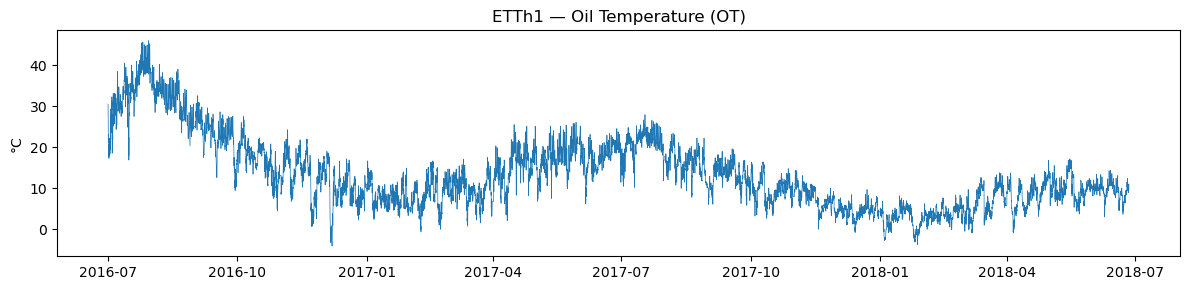

In [3]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(df.index, y, lw=0.5)
ax.set_title("ETTh1 — Oil Temperature (OT)")
ax.set_ylabel("°C")
plt.tight_layout()
plt.show()

In [4]:
split = int(0.8 * len(y))
y_train, y_test = y[:split], y[split:]
print(f"Train: {len(y_train)} pts  |  Test: {len(y_test)} pts")

Train: 13936 pts  |  Test: 3484 pts


In [5]:
HORIZONS = [1, 24, 96]

diag_basis = DiagonalPoly(p_degree=1, q_degree=1, spectral_norm=0.99)
model = SASForecaster(
    basis=diag_basis,
    n_reservoir=200,
    washout=100,
    chunk_size=128,
    n_cv_folds=3,
    seed=42,
)
model.fit(y_train, horizons=HORIZONS)
print("Ridge alphas selected:", model.alpha_log_)

TypeError: DiagonalPoly.__init__() missing 1 required positional argument: 'n'

In [ ]:
def streaming_eval(model, test, horizons):
    """
    Walk test set, predicting at every horizon then ingesting the current value.
    preds[h][t] is the forecast for test[t + h - 1] (when in bounds).
    """
    preds = {h: [] for h in horizons}
    for t in range(len(test)):
        for h in horizons:
            preds[h].append(model.predict(h))
        model.update(test[t])
    return {h: np.asarray(v) for h, v in preds.items()}

preds = streaming_eval(model, y_test, HORIZONS)

for h in HORIZONS:
    truth = y_test[h - 1:]
    pred  = preds[h][:len(truth)]
    mse   = np.mean((pred - truth) ** 2)
    mae   = np.mean(np.abs(pred - truth))
    print(f"h={h:>3d}  MSE={mse:8.3f}   MAE={mae:6.3f}")

h=  1  MSE=   0.417   MAE= 0.441
h= 24  MSE=   4.446   MAE= 1.670
h= 96  MSE=   8.999   MAE= 2.357


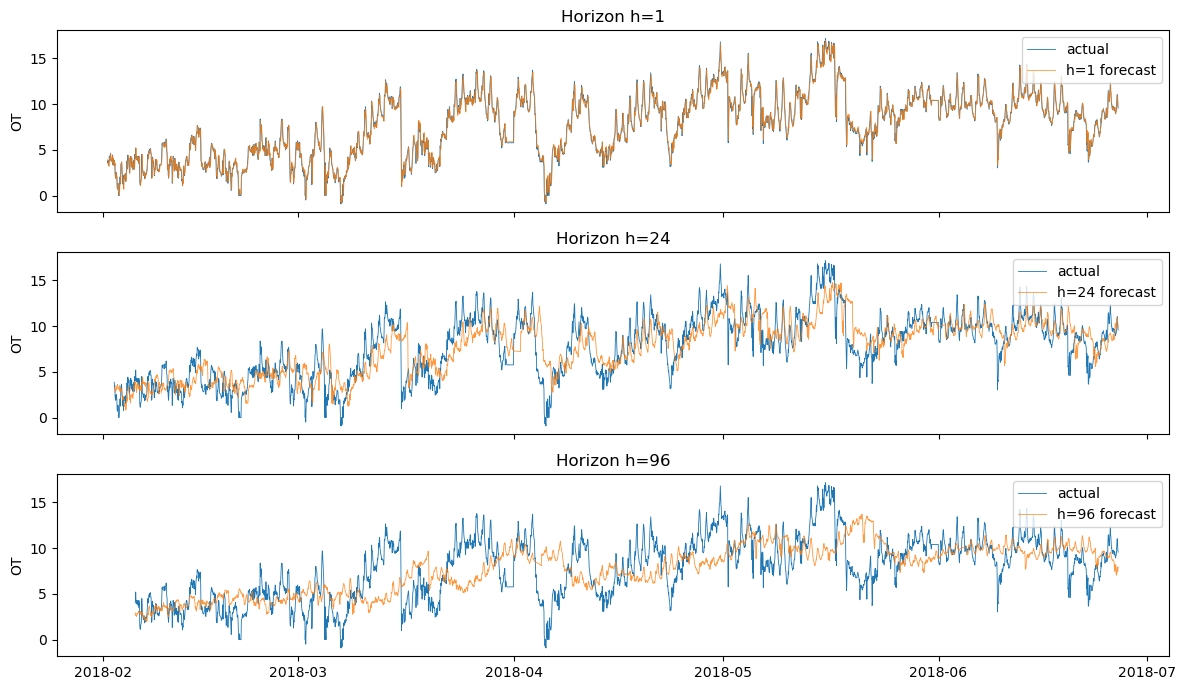

In [ ]:
fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(12, 7), sharex=True)
for ax, h in zip(axes, HORIZONS):
    truth = y_test[h - 1:]
    pred  = preds[h][:len(truth)]
    idx   = df.index[split + h - 1: split + h - 1 + len(truth)]
    ax.plot(idx, truth, lw=0.6, label="actual")
    ax.plot(idx, pred,  lw=0.6, label=f"h={h} forecast", alpha=0.8)
    ax.set_ylabel("OT")
    ax.legend(loc="upper right")
    ax.set_title(f"Horizon h={h}")
plt.tight_layout()
plt.show()

In [ ]:
lru_basis = LRUBlockPoly(
    p_degree=1, q_degree=1,
    tau_min=1.0, tau_max=200.0,
    frac_diagonal=0.5,
)
model_lru = SASForecaster(basis=lru_basis, n_reservoir=200, washout=100, seed=42)
model_lru.fit(y_train, horizons=HORIZONS)
preds_lru = streaming_eval(model_lru, y_test, HORIZONS)

print(f"{'h':>3}  {'Diagonal MSE':>14}  {'LRU MSE':>10}")
print("-" * 36)
for h in HORIZONS:
    truth = y_test[h - 1:]
    mse_d = np.mean((preds[h][:len(truth)]     - truth) ** 2)
    mse_l = np.mean((preds_lru[h][:len(truth)] - truth) ** 2)
    print(f"{h:>3d}  {mse_d:>14.3f}  {mse_l:>10.3f}")

  h    Diagonal MSE     LRU MSE
------------------------------------
  1           0.417       0.408
 24           4.446       4.778
 96           8.999       9.455
